In [50]:
import numpy as np
import csv
import matplotlib.pyplot as plt

# LHV_H2 = 0
# LHV_jetA = 1

# sfc_conversion_factor = LHV_H2/LHV_jetA
# SFC_H2 = SFC_jetA_2050 / sfc_conversion_factor

# (W_empty / W_0) = (W_empty / W_0)_plotfit + (W_tank/W_0) 
#W_tank calculated from G_i




#Requirements?
#PAX>350
with open("Data/JMPInputSheetFANS.csv", "r", encoding="utf-8-sig", newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    data = list(reader)

Aircraft = [row["AircraftDesignation"] for row in data]
EIS = [row["TLAR_EIS"] for row in data]

Aircraft_Passengers = [
    int(row["TLAR_MaxPax"]) if row["TLAR_MaxPax"].strip() else np.nan
    for row in data
]

Engine_EIS = [
    float(row["Engine_EIS"]) if row["Engine_EIS"].strip() else np.nan
    for row in data 
]

Engine_BPR = [
    float(row["Engine_BPR"]) if row["Engine_BPR"].strip() else np.nan
    for row in data
]

Engine_crs_SFC = [
    float(row["Engine_TSFC_Crs"]) if row["Engine_TSFC_Crs"].strip() else np.nan
    for row in data
] # lb/lbf/hr #CONVERT THIS!

#Cut data in Engine-cruise_SFC based on max passengers.
Engine_crs_SFC_paxrq = []
EIS_paxrq = []
for i in range(len(Engine_crs_SFC)):
    if Aircraft_Passengers[i] >= 350:
        Engine_crs_SFC_paxrq.append(Engine_crs_SFC[i])

for i in range(len(EIS)):
    if Aircraft_Passengers[i] >= 350:
        EIS_paxrq.append(EIS[i])
        
EIS_paxrq.sort()

print(EIS_paxrq)
print(len(EIS_paxrq))
print(Engine_crs_SFC_paxrq)
print(len(Engine_crs_SFC_paxrq))

['', '', '', '', '', '1969', '1970', '1970', '1970', '1970', '1970', '1971', '1972', '1972', '1973', '1973', '1973', '1974', '1976', '1979', '1979', '1981', '1983', '1983', '1983', '1984', '1985', '1987', '1988', '1988', '1989', '1989', '1989', '1989', '1990', '1991', '1992', '1992', '1993', '1994', '1994', '1995', '1995', '1995', '1995', '1995', '1995', '1995', '1995', '1998', '1998', '1998', '1998', '1999', '1999', '1999', '1999', '2000', '2000', '2000', '2000', '2000', '2000', '2002', '2002', '2002', '2002', '2002', '2002', '2003', '2004', '2006', '2006', '2006', '2007', '2007', '2007', '2007', '2010', '2010', '2011', '2011', '2014', '2014', '2014', '2017', '2018', '2018']
88
[0.67, 0.55, 0.55, 0.67, 0.55, 0.55, 0.542, 0.542, 0.542, 0.542, 0.4777, 0.4777, 0.4777, 0.58, 0.58, 0.63, nan, 0.58, nan, 0.56, nan, nan, nan, 0.584, nan, 0.584, 0.56, nan, nan, nan, nan, nan, 0.584, 0.584, 0.584, 0.5085, 0.5085, 0.62, nan, 0.63, 0.62, 0.63, 0.63, 0.63, 0.62, 0.799, 0.63, 0.63, 0.63, nan, 0.63

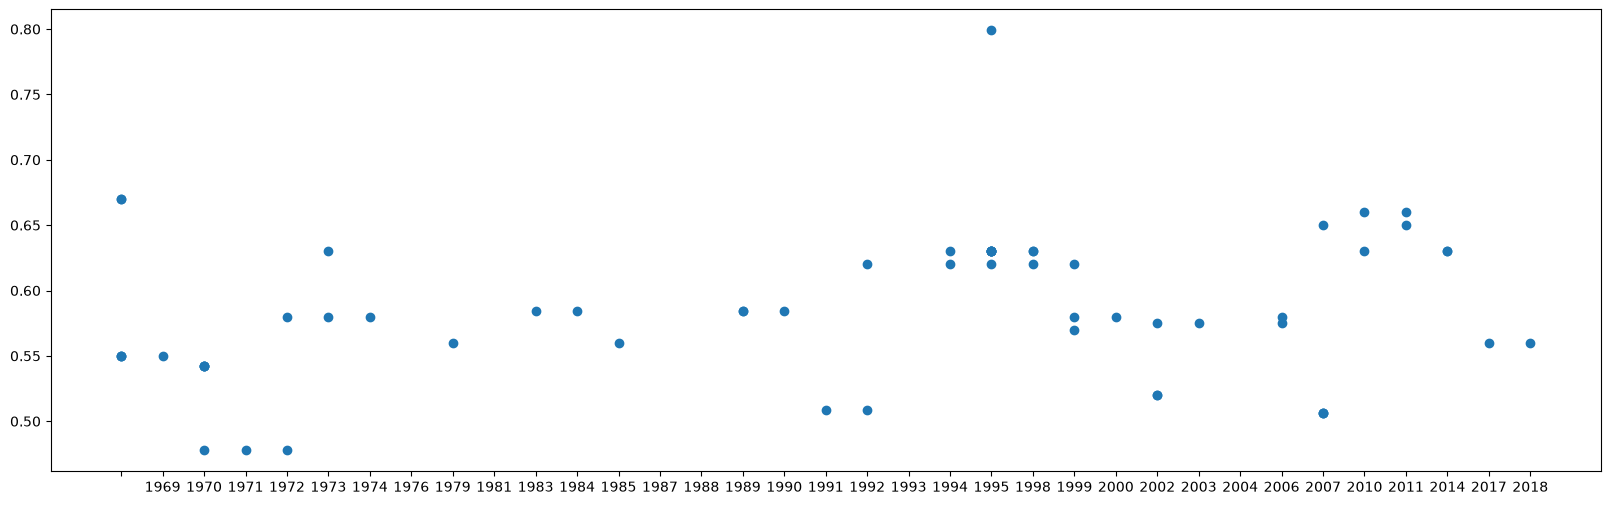

In [51]:
plt.figure(figsize=(20, 6))
plt.scatter(EIS_paxrq, Engine_crs_SFC_paxrq)

NumPy is working: True
